# HaluEval: Hallucination Detection via Semantic Entropy & Embedding Geometry

HaluEval is a hallucination evaluation benchmark. Responses were generated by Flan-T5-Base at temperature 1.0 (20 per question) and judged by GPT-4-mini into correct, incorrect, or refused.

Key characteristics:
- 500 questions, 10,000 responses
- Very high correct rate (~89.8%) — most questions are easy for the model
- Minimal refusals (10 total)
- 30 raw domain labels with moderate sprawl
- No adversarial questions
- `type` column is empty (not meaningful)

**Pipeline overview:**
1. Load and inspect the raw response-level data
2. Response-level EDA (label breakdown by domain)
3. Domain analysis (raw domains, canonical consolidation, consistency)
4. Embed all responses with SentenceTransformer
5. Extract 5 geometric features per question
6. Question-level EDA (label profiles, naive vs strict rates)
7. Geometric feature exploration (distributions, correlations, pairplot)
8. Statistical tests (KS tests, permutation test)
9. Classification and ablation
10. Feature importance and SHAP
11. UMAP visualisation (optional)


## Setup

In [1]:
# Uncomment to install dependencies:
# !pip install -q sentence-transformers scikit-learn xgboost scipy shap matplotlib seaborn umap-learn

import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sys.path.insert(0, '.')

from hallucination_utils import *

print('All imports loaded.')
%load_ext autoreload
%autoreload 2

All imports loaded.


## Configuration

In [2]:
# ── Paths ──
DATA_PATH = './data/halueval_t1.0_n20.jsonl'
OUTPUT_DIR = 'halueval_output'
EMBED_CACHE = 'halueval_embeddings.npy'

# ── Feature extraction ──
SIM_THRESHOLD = 0.85

# ── Statistical tests ──
N_PERMUTATIONS = 10000
N_BOOTSTRAP = 2000
RANDOM_SEED = 42

# ── Per-domain ML threshold ──
MIN_QUESTIONS_FOR_ANALYSIS = 10

os.makedirs(OUTPUT_DIR, exist_ok=True)
np.random.seed(RANDOM_SEED)


## Load Data

`load_dataset()` handles column normalisation, ensures `prompt_id` exists,
and adds `answer_len`.


In [3]:
df = load_dataset(DATA_PATH)
print_loading_summary(df)


Dataset:          halueval
Total rows:       10000
Unique questions: 500
Samples/question: min=20, max=20, median=20.0

Correctness distribution:
  correct     :   8984  (89.8%)
  incorrect   :   1006  (10.1%)
  refused     :     10  (0.1%)

Domains (30 unique)  (showing 10 of 30):
  Business
  Business, Food & Beverage
  Business, Hospitality, Entertainment
  Business, Industry, and Miscellaneous
  Business, Law, and Miscellaneous
  Business, Miscellaneous
  Business, Non-profit
  Business, Social Sciences
  Business, Technology
  Business, and Miscellaneous
  ...


In [4]:
# Question-level metadata
q_meta = compute_question_metadata(df)
print_domain_consistency(q_meta)


Domain inconsistency: 104/500 questions (20.8%)
Max unique domains per question: 5


In [5]:
# Raw questions per domain (top 15)
raw_domain_counts = questions_per_domain(df)
print(f'Questions per domain (raw) — {len(raw_domain_counts)} domains:')
for dom, n in raw_domain_counts.head(15).items():
    print(f'  {dom:45s}: {n}')
if len(raw_domain_counts) > 15:
    print(f'  ... and {len(raw_domain_counts) - 15} more domains')


Questions per domain (raw) — 30 domains:
  Humanities                                   : 276
  STEM                                         : 122
  Social Sciences                              : 115
  Music                                        : 26
  Law, Business, and Miscellaneous             : 21
  Sports                                       : 18
  Business                                     : 13
  Entertainment                                : 7
  Business, Law, and Miscellaneous             : 7
  Medicine & Health                            : 7
  Business, Miscellaneous                      : 3
  Media & Entertainment                        : 2
  Sports & Entertainment                       : 2
  Business, Social Sciences                    : 2
  Comics/Pop Culture                           : 1
  ... and 15 more domains


## Domain Analysis

HaluEval has 30 raw domains from the LLM judge, with moderate sprawl. We use `domain_mode` (majority vote per question) and optionally consolidate to canonical categories.


In [6]:
# Apply canonical domain consolidation
df = add_canonical_domain(df)
q_meta_canon = compute_question_metadata(df, domain_col='domain_canonical')

canon_counts = questions_per_domain(df, domain_col='domain_canonical')
print(f'Canonical domains ({len(canon_counts)}):')
for dom, n in canon_counts.items():
    print(f'  {dom:30s}: {n}')

print()
print_domain_consistency(q_meta_canon)


Canonical domains (9):
  Humanities                    : 276
  STEM                          : 122
  Social Sciences               : 115
  Entertainment                 : 37
  Law & Business                : 27
  Sports                        : 19
  Medicine & Health             : 7
  Food & Nutrition              : 2
  History                       : 1

Domain inconsistency: 95/500 questions (19.0%)
Max unique domains per question: 3


## Response-Level EDA

Label breakdown at the response level, using both raw and canonical domains.


In [7]:
# Response-level counts
resp_counts = df['correctness'].value_counts()
resp_pcts = (resp_counts / len(df) * 100).round(1)
print('Response-level label distribution:')
for lab in LABEL_ORDER:
    if lab in resp_counts.index:
        print(f'  {lab:12s}: {resp_counts[lab]:6d}  ({resp_pcts[lab]:.1f}%)')


Response-level label distribution:
  correct     :   8984  (89.8%)
  incorrect   :   1006  (10.1%)
  refused     :     10  (0.1%)


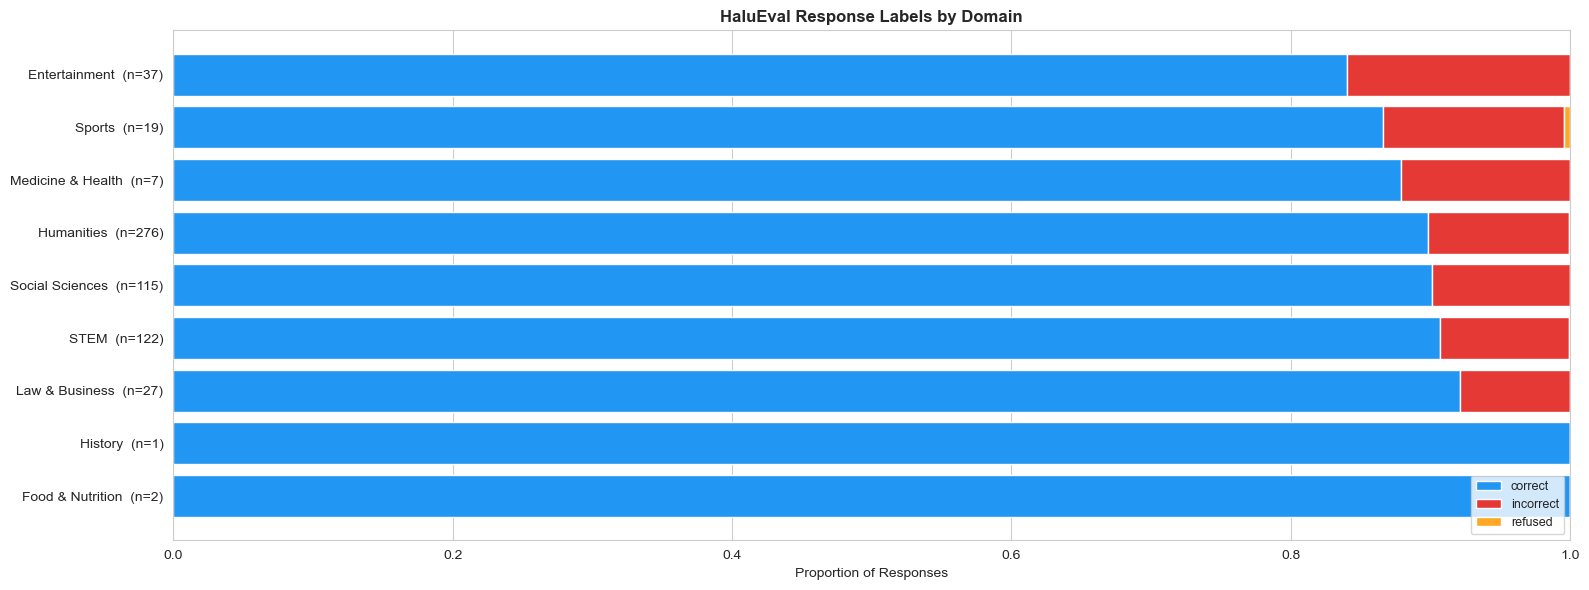

In [8]:
# Stacked bar: canonical domains
fig = plot_response_label_breakdown(
    df,
    domain_col='domain_canonical',
    domain_question_counts=canon_counts,
    title_prefix='HaluEval Response Labels',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig01_response_label_breakdown.png'), dpi=150, bbox_inches='tight')
plt.show()


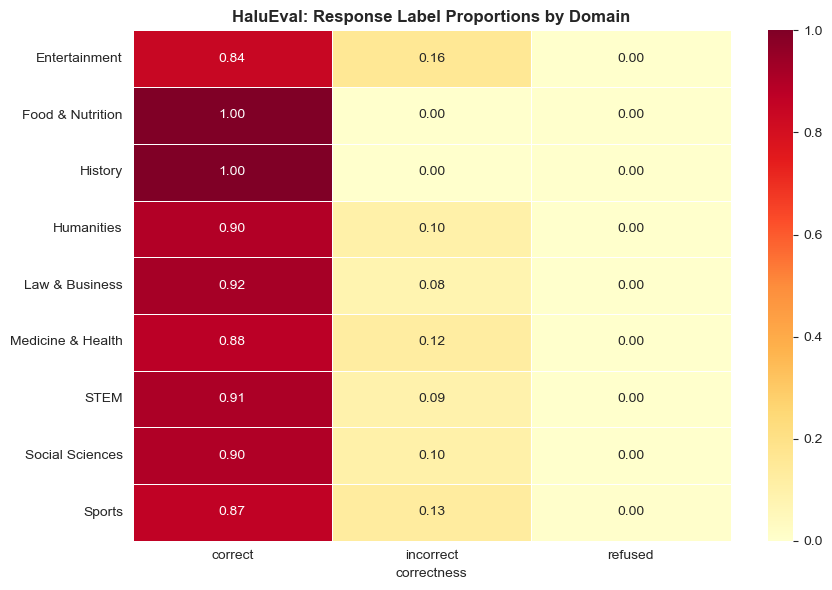

In [9]:
# Heatmap: canonical domains
fig = plot_label_proportion_heatmap(
    df,
    domain_col='domain_canonical',
    title='HaluEval: Response Label Proportions by Domain',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig02_response_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()


## Embed All Responses

We embed every response regardless of correctness label. The geometric
features use all 20 embeddings per question.


In [10]:
all_embeddings = embed_responses(
    df,
    model_name='all-MiniLM-L6-v2',
    cache_path=EMBED_CACHE,
    batch_size=256,
)
print(f'Embedding matrix: {all_embeddings.shape}')


Loading cached embeddings from halueval_embeddings.npy
Embedding matrix: (10000, 384)


## Feature Extraction

Per question: 5 geometric features from all 20 embeddings, label fractions,
strict hallucination rate (excluding refused from denominator), and binary label.


In [11]:
mu_ref, cov_inv = fit_reference_distribution(all_embeddings, df)


Correct responses for reference: 8984
Reference fitted. mu shape: (384,), precision shape: (384, 384)


In [12]:
feat_df, skipped, skipped_details = extract_question_features(
    df, all_embeddings, mu_ref, cov_inv,
    sim_threshold=SIM_THRESHOLD,
    domain_col='domain_canonical',
)

feat_df.to_csv(os.path.join(OUTPUT_DIR, 'halueval_features.csv'), index=False)


  500/500 ...

Questions processed: 500
Questions skipped (all refused): 0
Label distribution:
  Correct (0): 464
  Hallucinated (1): 36
  Rate: 7.2%


### Filtering Diagnostic

In [13]:
canon_raw_counts = questions_per_domain(df, domain_col='domain_canonical')
analysis_domains, excluded_domains = print_filtering_diagnostic(
    feat_df, canon_raw_counts, skipped, MIN_QUESTIONS_FOR_ANALYSIS,
    domain_col='domain_canonical', skipped_details=skipped_details,
)


No questions were skipped.

Surviving questions per domain:
  Humanities                              :  248 /  276  (dropped 28)
  STEM                                    :  105 /  122  (dropped 17)
  Social Sciences                         :   88 /  115  (dropped 27)
  Law & Business                          :   22 /   27  (dropped 5)
  Entertainment                           :   19 /   37  (dropped 18)
  Sports                                  :   11 /   19  (dropped 8)
  Medicine & Health                       :    7 /    7  (dropped 0)  *** BELOW THRESHOLD

Domains for ML (>= 10 questions): 6
Excluded: ['Medicine & Health']


## Question-Level EDA

Per-question label profiles and naive vs strict hallucination rate comparison.


In [14]:
frac_cols = ['frac_correct', 'frac_incorrect', 'frac_refused']
print('Per-question label fraction statistics:')
display(feat_df[frac_cols + ['hall_rate_strict', 'hall_rate_naive']].describe().round(3))


Per-question label fraction statistics:


,frac_correct,frac_incorrect,frac_refused,hall_rate_strict,hall_rate_naive
count,500.000,500.000,500.000,500.000,500.000
mean,0.898,0.101,0.001,0.101,0.102
std,0.218,0.216,0.009,0.218,0.218
min,0.000,0.000,0.000,0.000,0.000
25%,0.950,0.000,0.000,0.000,0.000
50%,1.000,0.000,0.000,0.000,0.000
75%,1.000,0.050,0.000,0.050,0.050
max,1.000,1.000,0.150,1.000,1.000


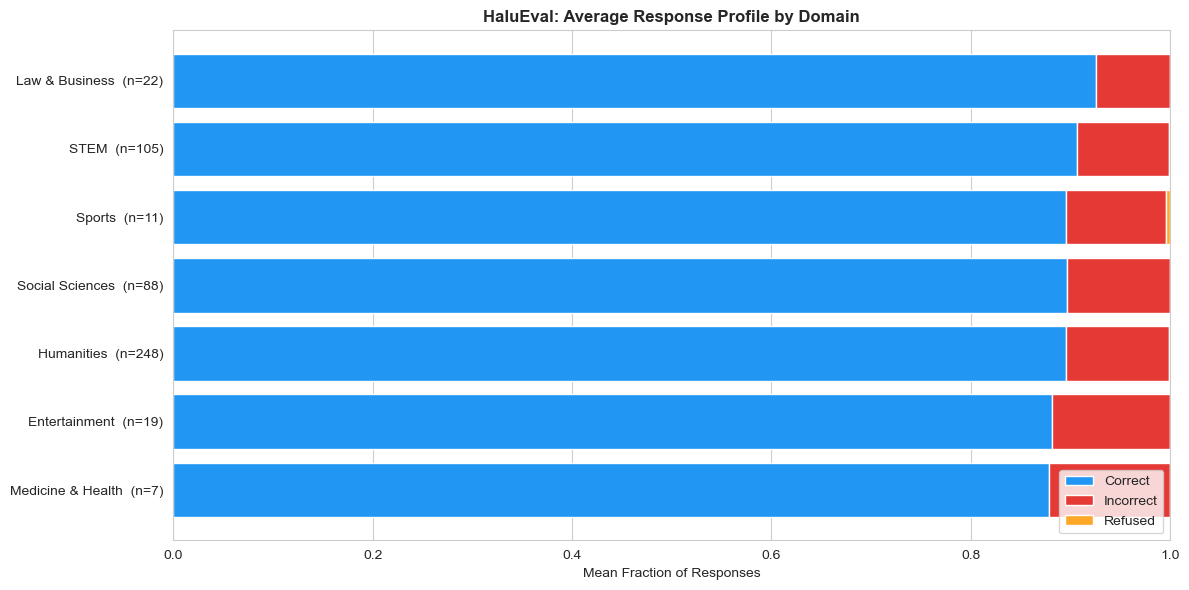

In [15]:
fig = plot_question_label_profiles(
    feat_df,
    frac_cols=['frac_correct', 'frac_incorrect', 'frac_refused'],
    frac_nice_names=['Correct', 'Incorrect', 'Refused'],
    frac_colors=[LABEL_COLORS['correct'], LABEL_COLORS['incorrect'], LABEL_COLORS['refused']],
    domain_col='domain_canonical',
    title='HaluEval: Average Response Profile by Domain',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig04_question_label_profiles.png'), dpi=150, bbox_inches='tight')
plt.show()


### Domain Summary Table

In [16]:
domain_stats = build_domain_stats(
    feat_df,
    strict_rate_col='hall_rate_strict',
    domain_col='domain_canonical',
    extra_mean_cols=['frac_refused'],
    analysis_domains=analysis_domains,
)
display(domain_stats.round(3))
domain_stats.to_csv(os.path.join(OUTPUT_DIR, 'domain_stats.csv'))


,n_questions,n_hallucinated,hall_rate_mean,hall_rate_std,mean_entropy,mean_frac_refused,pct_hallucinated,in_analysis
domain_canonical,,,,,,,,
Medicine & Health,7,1,0.121,0.300,0.765,0.000,14.3,False
Entertainment,19,2,0.118,0.263,0.569,0.000,10.5,True
Humanities,248,19,0.104,0.228,0.742,0.001,7.7,True
Social Sciences,88,5,0.103,0.200,0.868,0.001,5.7,True
Sports,11,1,0.102,0.186,0.965,0.005,9.1,True
STEM,105,7,0.093,0.207,0.743,0.001,6.7,True
Law & Business,22,1,0.075,0.181,0.938,0.000,4.5,True


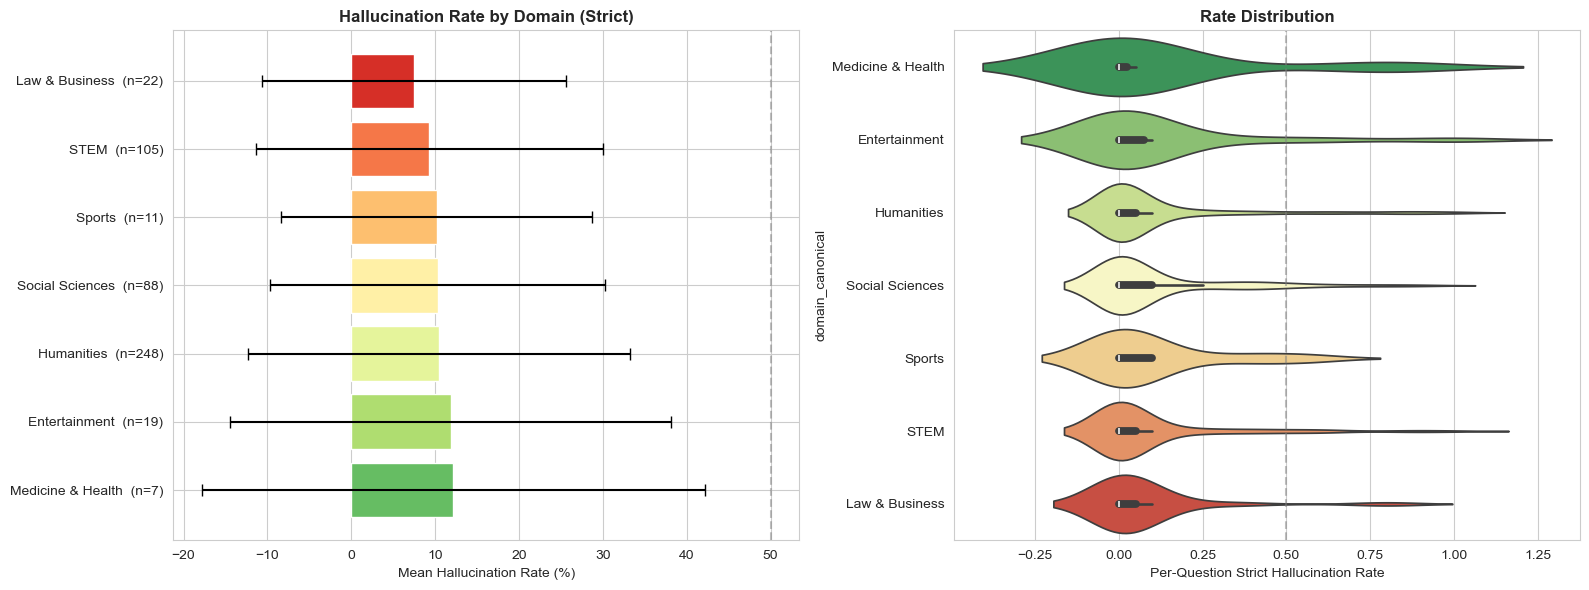

In [17]:
fig = plot_hallucination_rate_by_domain(
    feat_df, domain_stats,
    strict_rate_col='hall_rate_strict',
    domain_col='domain_canonical',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig07_hallu_rate_by_domain.png'), dpi=150, bbox_inches='tight')
plt.show()


## Geometric Feature Distributions

The 5 embedding-geometry features, split by the binary target label.


In [18]:
for lab, tag in [(0, 'Correct'), (1, 'Hallucinated')]:
    sub = feat_df[feat_df['label'] == lab]
    print(f'--- {tag} (n={len(sub)}) ---')
    display(sub[GEO_FEATURES].describe().round(4))


--- Correct (n=464) ---


,H_sem,D_cos,M_bar,K,sig2_S
count,464.0000,464.0000,464.0000,464.0000,464.0000
mean,0.6784,0.0627,18.3755,2.8168,0.0287
std,0.8263,0.0813,3.8409,2.4572,0.0406
min,-0.0000,-0.0000,8.0276,1.0000,0.0000
25%,-0.0000,0.0028,16.2469,1.0000,0.0001
50%,0.2864,0.0286,18.0523,2.0000,0.0081
75%,1.1267,0.0930,20.1123,4.0000,0.0468
max,3.9219,0.4556,37.1246,17.0000,0.2523


--- Hallucinated (n=36) ---


,H_sem,D_cos,M_bar,K,sig2_S
count,36.0000,36.0000,36.0000,36.0000,36.0000
mean,1.9716,0.1957,24.2360,7.3056,0.0652
std,1.2745,0.1342,8.7052,5.3762,0.0297
min,-0.0000,0.0078,6.9421,1.0000,0.0011
25%,0.9189,0.0867,20.6703,3.0000,0.0508
50%,1.7011,0.1656,26.5558,5.0000,0.0642
75%,3.0570,0.3054,30.5156,10.2500,0.0807
max,4.3219,0.4722,37.2827,20.0000,0.1436


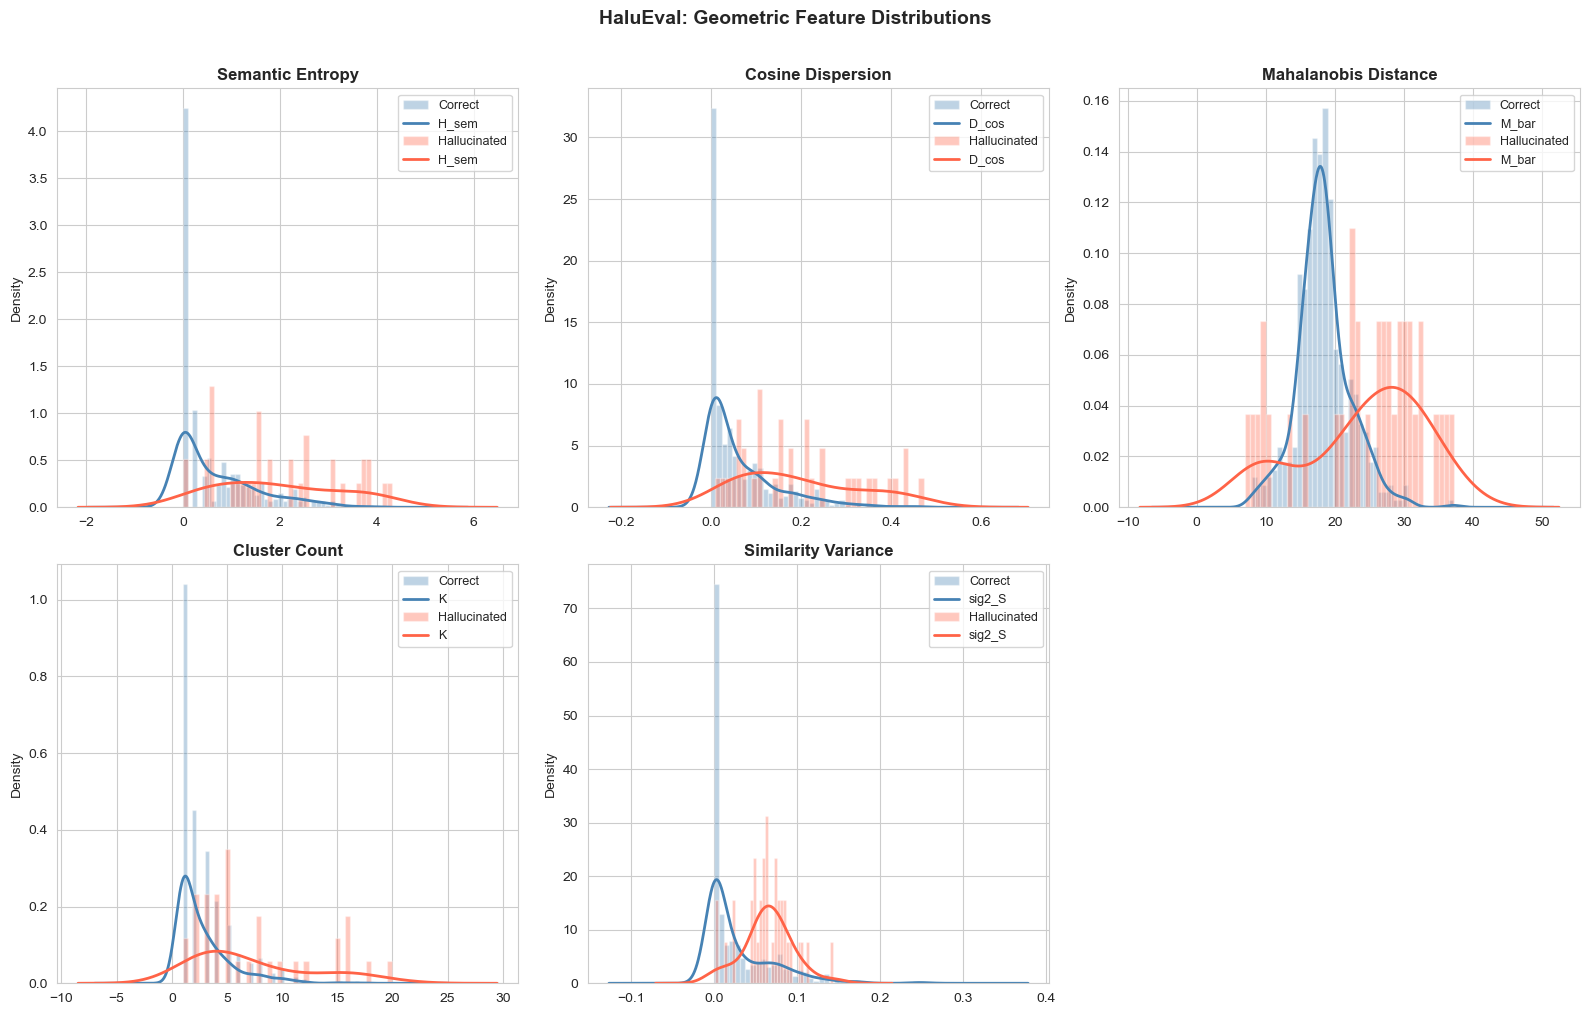

In [19]:
fig = plot_feature_distributions(
    feat_df,
    suptitle='HaluEval: Geometric Feature Distributions',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig08_feature_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()


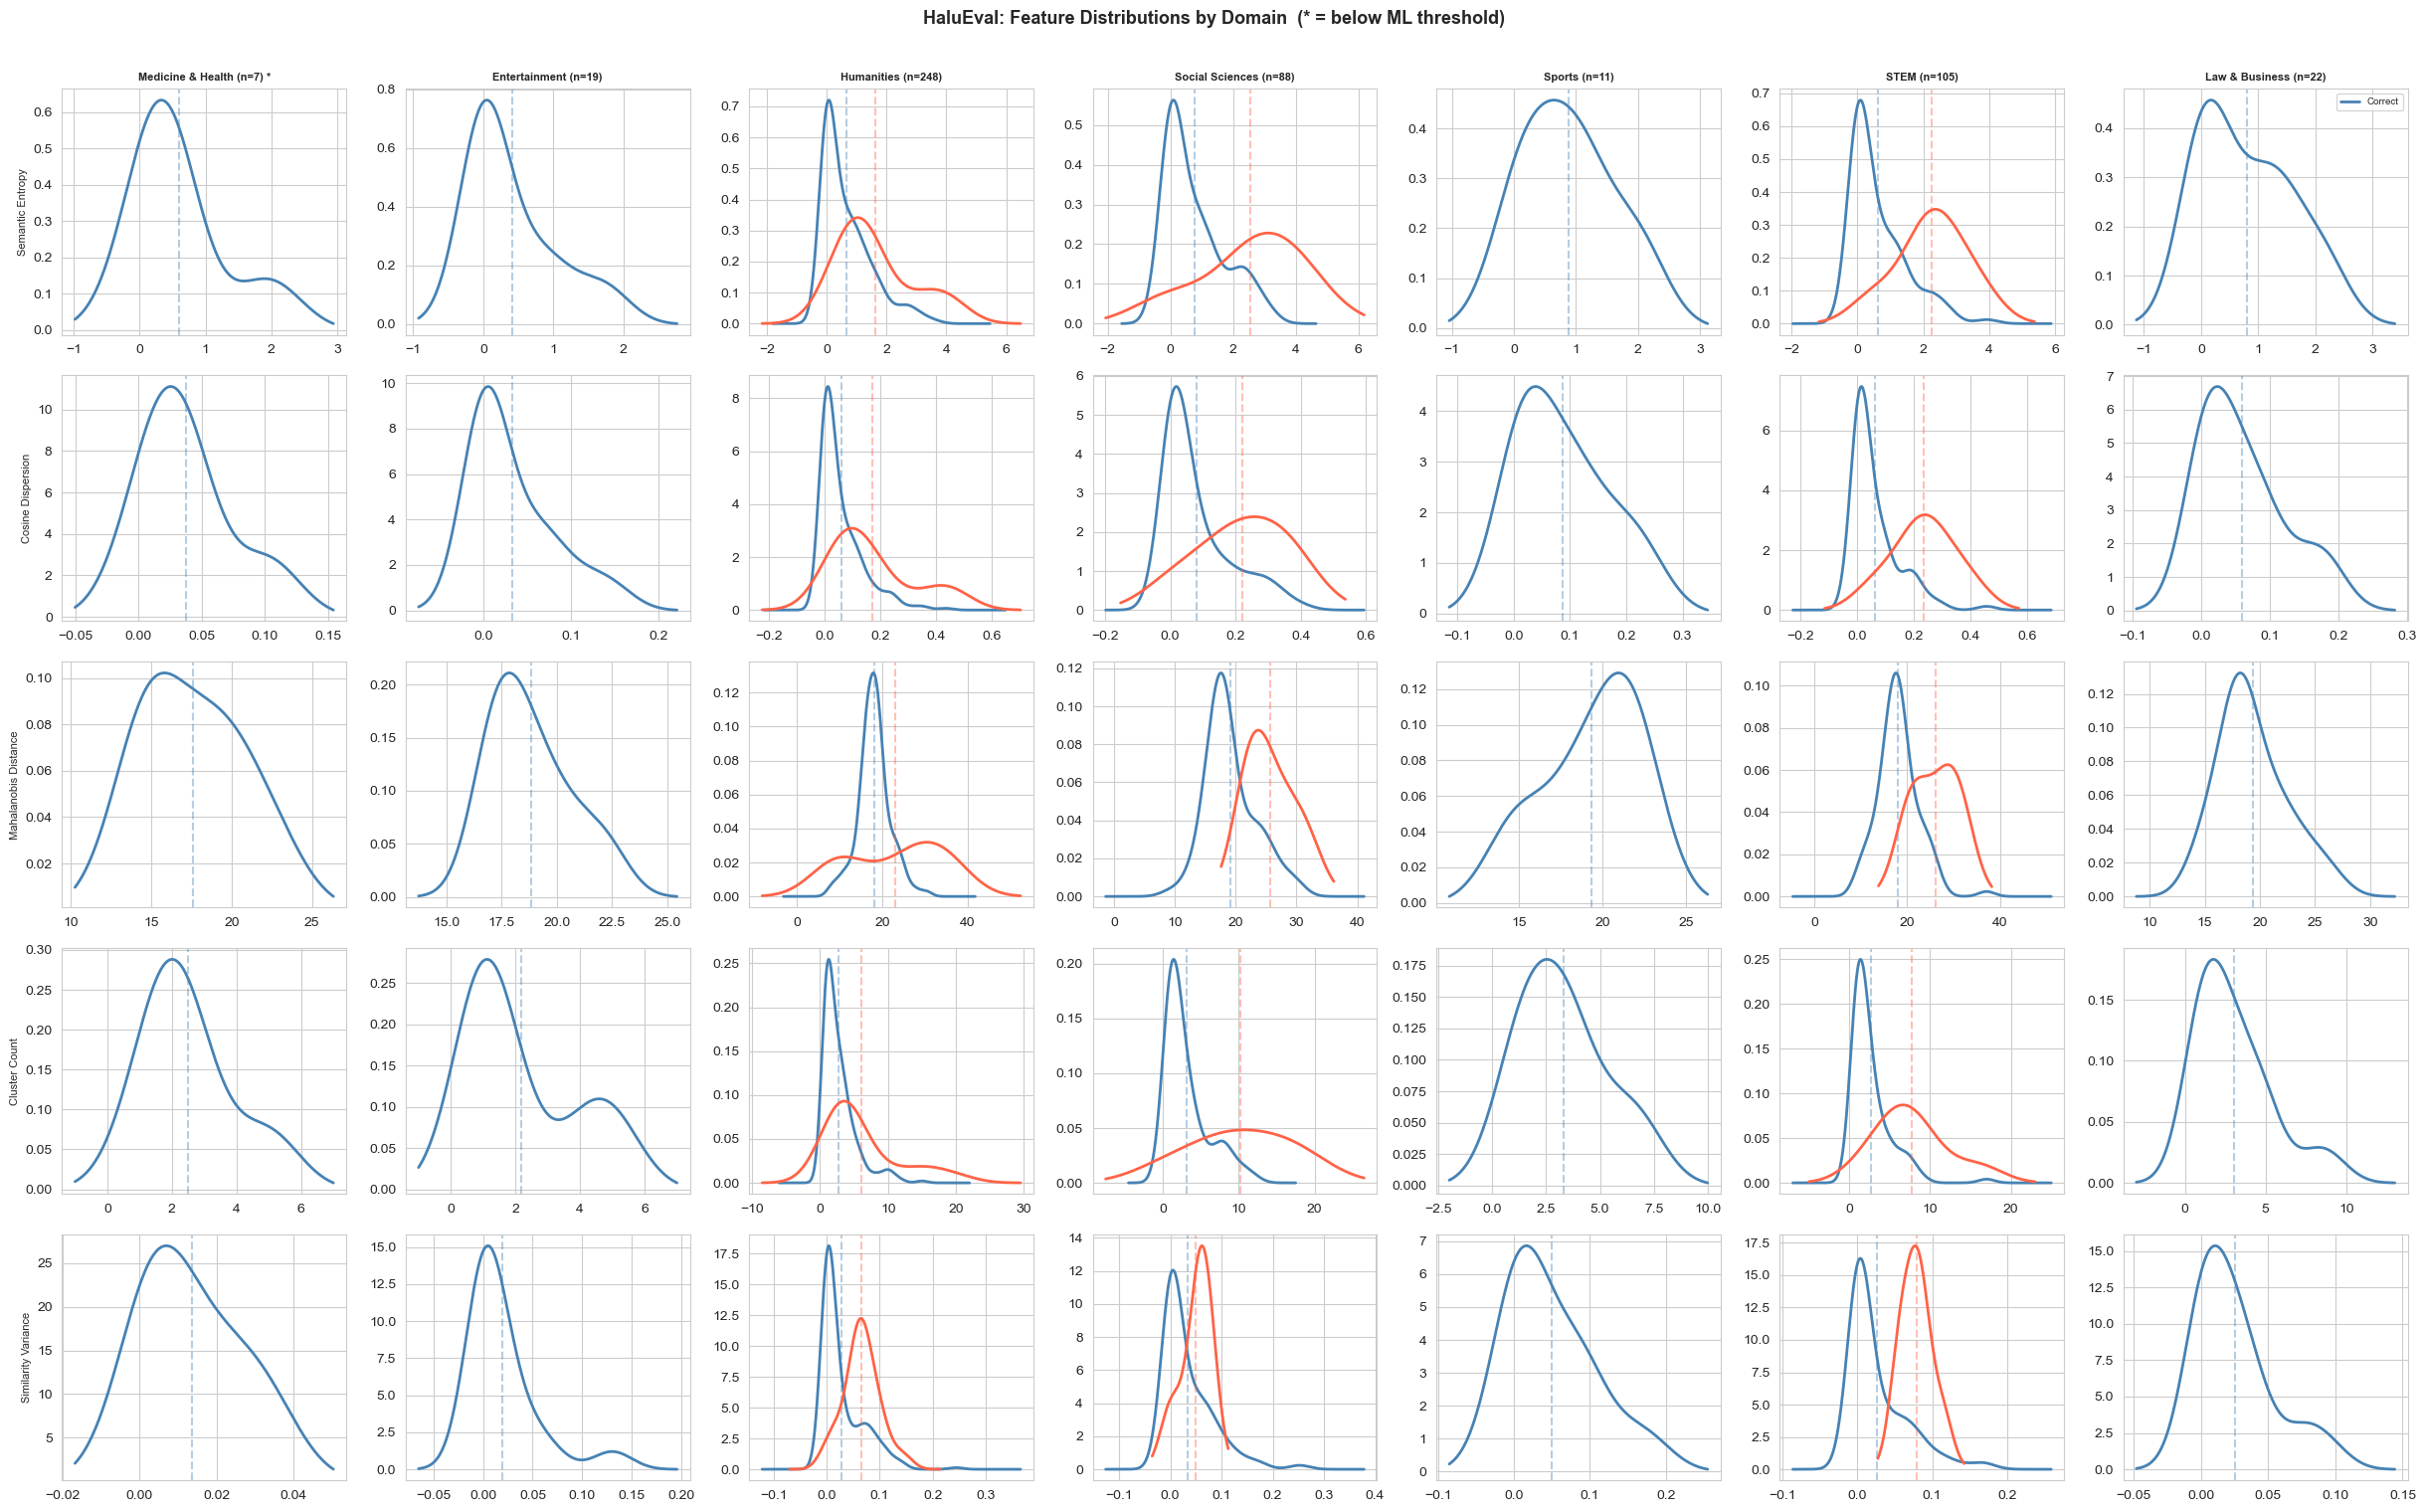

In [20]:
domains_ordered = domain_stats.reset_index()['domain_canonical'].tolist()

fig = plot_per_domain_feature_kdes(
    feat_df,
    domains_ordered=domains_ordered,
    domain_col='domain_canonical',
    analysis_domains=analysis_domains,
    suptitle='HaluEval: Feature Distributions by Domain',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig09_kde_by_domain.png'), dpi=120, bbox_inches='tight')
plt.show()


### Correlation Analysis

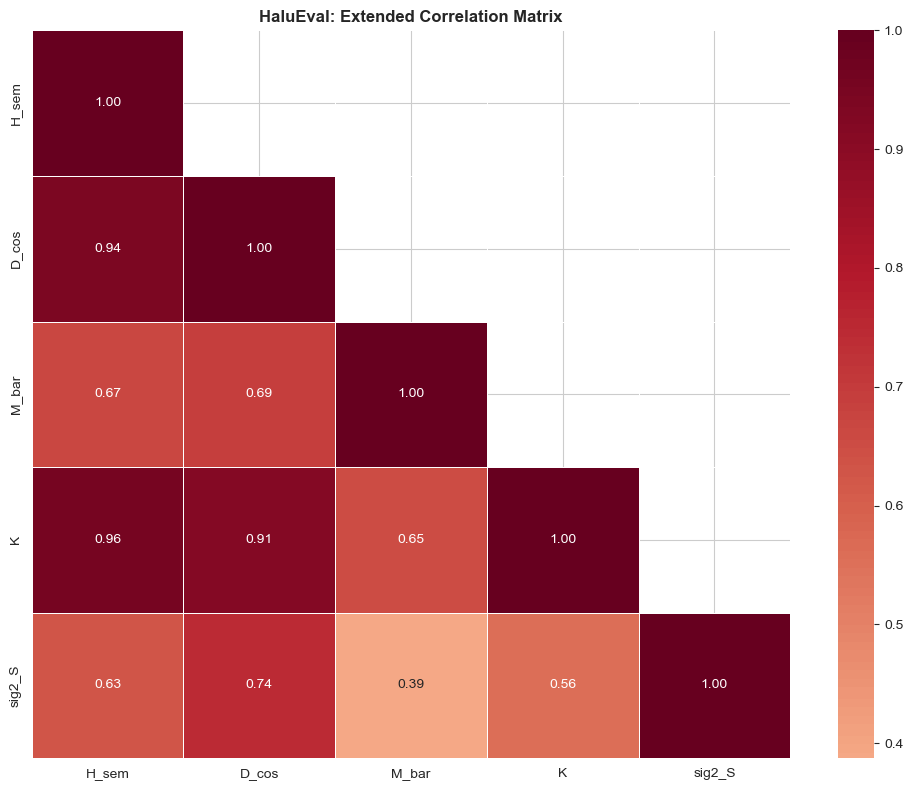

In [21]:
corr_cols = GEO_FEATURES 
fig = plot_correlation_matrix(
    feat_df, cols=corr_cols,
    title='HaluEval: Extended Correlation Matrix',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig10_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()


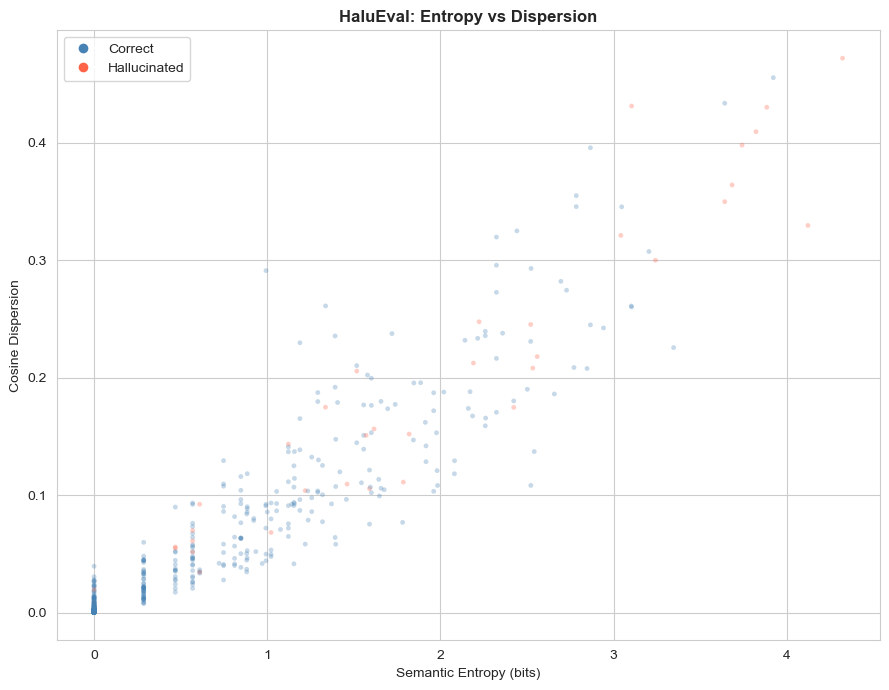

In [22]:
fig = plot_entropy_vs_dispersion(feat_df, title='HaluEval: Entropy vs Dispersion')
plt.savefig(os.path.join(OUTPUT_DIR, 'fig11_entropy_vs_dispersion.png'), dpi=150, bbox_inches='tight')
plt.show()


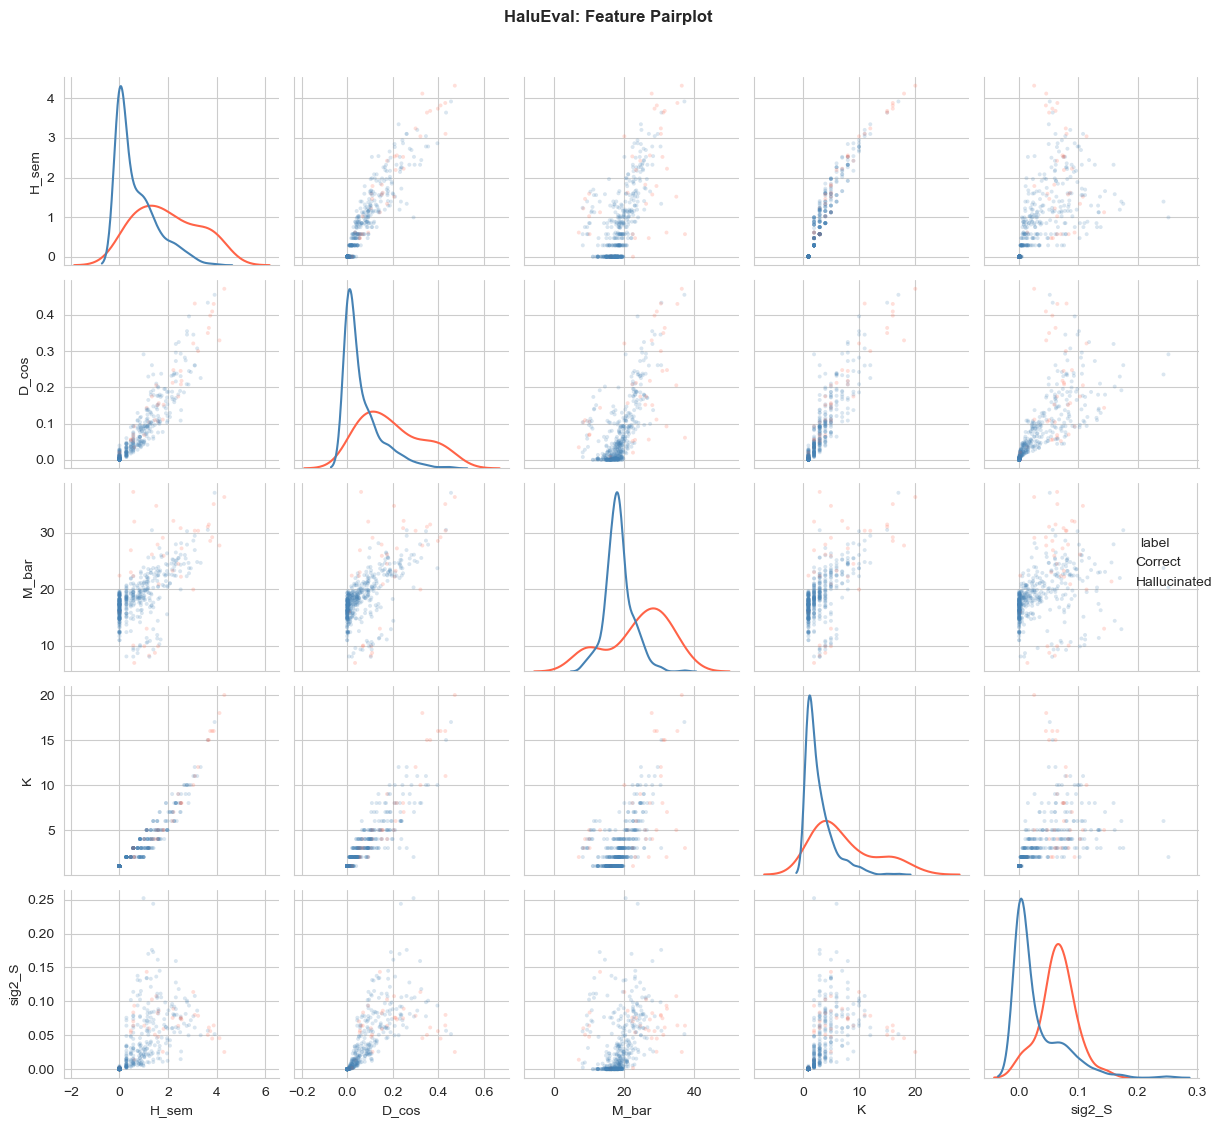

In [23]:
fig = plot_feature_pairplot(feat_df, suptitle='HaluEval: Feature Pairplot')
plt.savefig(os.path.join(OUTPUT_DIR, 'fig12_pairplot.png'), dpi=100, bbox_inches='tight')
plt.show()


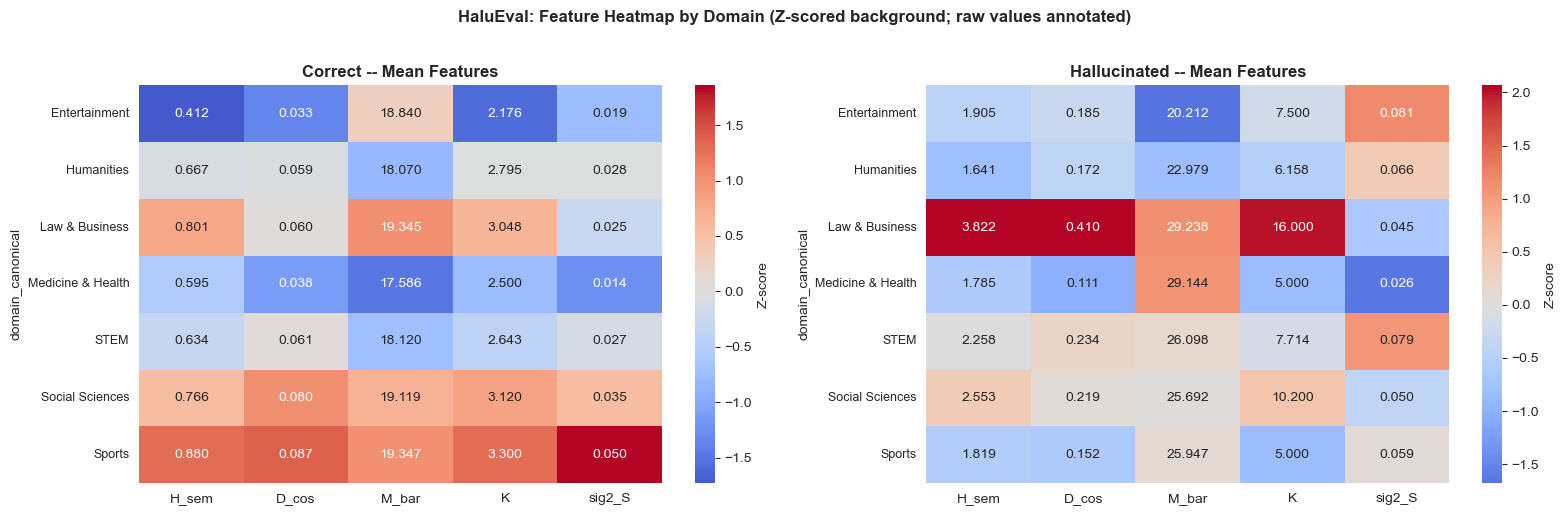

In [24]:
fig = plot_domain_feature_heatmaps(
    feat_df, domain_col='domain_canonical',
    suptitle='HaluEval: Feature Heatmap by Domain',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig13_domain_heatmaps.png'), dpi=150, bbox_inches='tight')
plt.show()


## Statistical Tests

### KS Tests — Global and Per-Domain


In [25]:
from scipy.stats import ks_2samp

print('Global KS tests (Bonferroni alpha = 0.01):')
ks_global = []
for feat in GEO_FEATURES:
    g0 = feat_df.loc[feat_df['label'] == 0, feat].values
    g1 = feat_df.loc[feat_df['label'] == 1, feat].values
    if len(g0) < 2 or len(g1) < 2:
        continue
    stat, p = ks_2samp(g0, g1)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    ks_global.append({'Feature': feat, 'KS_stat': stat, 'p_value': p, 'sig': sig})
    print(f'  {feat:10s}  D={stat:.4f}  p={p:.2e}  {sig}')

pd.DataFrame(ks_global).to_csv(os.path.join(OUTPUT_DIR, 'ks_tests_global.csv'), index=False)


Global KS tests (Bonferroni alpha = 0.01):
  H_sem       D=0.4770  p=1.75e-07  ***
  D_cos       D=0.5417  p=1.18e-09  ***
  M_bar       D=0.5649  p=1.56e-10  ***
  K           D=0.4571  p=6.92e-07  ***
  sig2_S      D=0.6025  p=4.69e-12  ***


In [26]:
all_domains = sorted(feat_df['domain_canonical'].unique())
n_tests = len(GEO_FEATURES) * len(all_domains)
alpha_bonf = 0.05 / n_tests
print(f'Tests: {n_tests}, Bonferroni alpha: {alpha_bonf:.6f}')

ks_rows = []
for dom in all_domains:
    df_d = feat_df[feat_df['domain_canonical'] == dom]
    for feat in GEO_FEATURES:
        g0 = df_d[df_d['label'] == 0][feat].values
        g1 = df_d[df_d['label'] == 1][feat].values
        if len(g0) < 2 or len(g1) < 2:
            continue
        stat, p = ks_2samp(g0, g1)
        ks_rows.append({
            'Domain': dom, 'Feature': feat,
            'KS_stat': round(stat, 4), 'p_value': p,
            'Significant': p < alpha_bonf,
            'n_questions': len(df_d),
        })

df_ks = pd.DataFrame(ks_rows)
df_ks.to_csv(os.path.join(OUTPUT_DIR, 'ks_tests_per_domain.csv'), index=False)
display(df_ks)


Tests: 35, Bonferroni alpha: 0.001429


,Domain,Feature,KS_stat,p_value,Significant,n_questions
0,Entertainment,H_sem,0.7059,0.245614,False,19
1,Entertainment,D_cos,0.7647,0.175439,False,19
2,Entertainment,M_bar,0.5000,0.625731,False,19
3,Entertainment,K,0.7059,0.245614,False,19
4,Entertainment,sig2_S,0.9412,0.035088,False,19
5,Humanities,H_sem,0.4583,0.000668,True,248
6,Humanities,D_cos,0.5323,0.000037,True,248
7,Humanities,M_bar,0.5045,0.000124,True,248
8,Humanities,K,0.3739,0.010609,False,248
9,Humanities,sig2_S,0.6019,0.000002,True,248


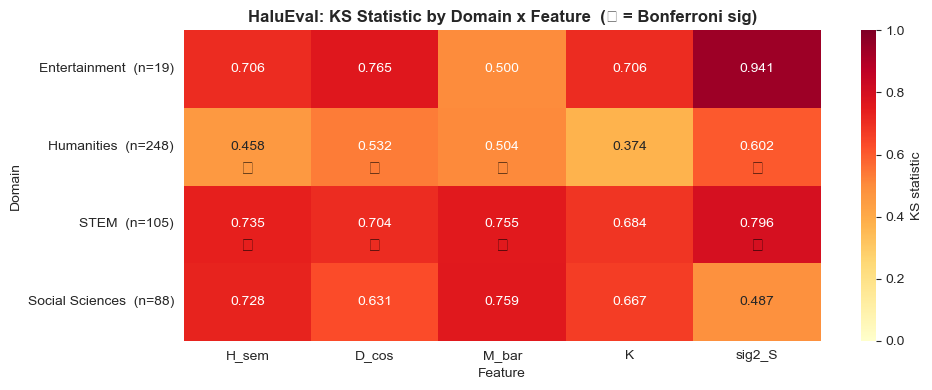

In [27]:
survived_counts = feat_df['domain_canonical'].value_counts()
fig = plot_ks_heatmap(
    df_ks, survived_counts=survived_counts,
    title='HaluEval: KS Statistic by Domain x Feature',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig14_ks_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()


### Permutation Test on Entropy Difference

Observed delta (hallu - correct): 1.2933 bits
Permutation p-value (10000 iters): 0.000000


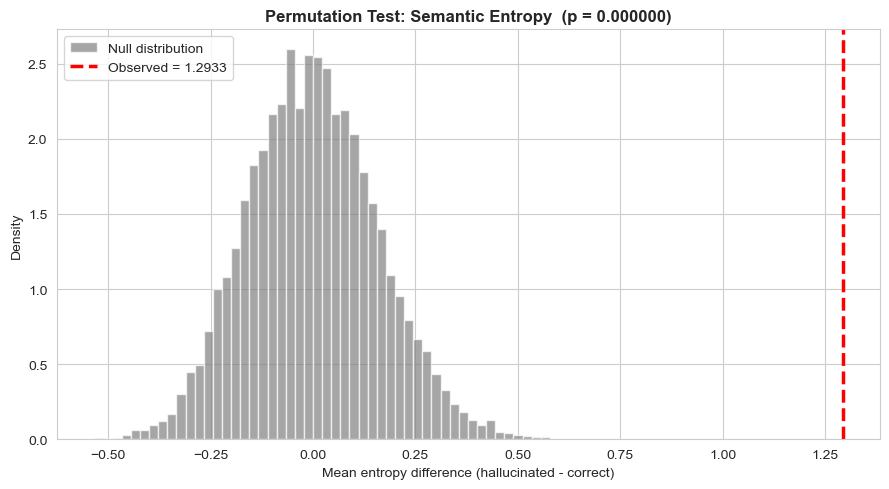

In [28]:
ent_correct = feat_df.loc[feat_df['label'] == 0, 'H_sem'].values
ent_hallu   = feat_df.loc[feat_df['label'] == 1, 'H_sem'].values
delta_obs   = ent_hallu.mean() - ent_correct.mean()
print(f'Observed delta (hallu - correct): {delta_obs:.4f} bits')

all_ent    = feat_df['H_sem'].values
all_labels = feat_df['label'].values
rng = np.random.default_rng(RANDOM_SEED)

perm_deltas = np.zeros(N_PERMUTATIONS)
for p in range(N_PERMUTATIONS):
    shuffled = rng.permutation(all_labels)
    perm_deltas[p] = all_ent[shuffled == 1].mean() - all_ent[shuffled == 0].mean()

perm_pval = (perm_deltas >= delta_obs).sum() / N_PERMUTATIONS
print(f'Permutation p-value ({N_PERMUTATIONS} iters): {perm_pval:.6f}')

fig = plot_permutation_test(perm_deltas, delta_obs, N_PERMUTATIONS, perm_pval)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig15_permutation_test.png'), dpi=150, bbox_inches='tight')
plt.show()


## Classification and Ablation

Feature subsets × classifiers using 5-fold stratified CV.


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from collections import Counter
import xgboost as xgb

EXTENDED_FEATURES = GEO_FEATURES 

X_geo = feat_df[GEO_FEATURES].values
X_ext = feat_df[EXTENDED_FEATURES].values
y_all = feat_df['label'].values

scaler_geo = StandardScaler()
scaler_ext = StandardScaler()
X_geo_sc = scaler_geo.fit_transform(X_geo)
X_ext_sc = scaler_ext.fit_transform(X_ext)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_SEED),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        eval_metric='logloss', random_state=RANDOM_SEED, verbosity=0,
    ),
}

ablation_sets = {
    'Entropy only (H_sem)':        ('geo', [0]),
    'Geometry only (D_cos, M_bar)': ('geo', [1, 2]),
    'Entropy + Geometry':           ('geo', [0, 1, 2]),
    'All 5 geometric':              ('geo', [0, 1, 2, 3, 4]),
    'All 5 + refused':              ('ext', list(range(len(EXTENDED_FEATURES)))),
}

clf_rows = []
for variant, (fset, feat_idx) in ablation_sets.items():
    X_use = X_geo_sc if fset == 'geo' else X_ext_sc
    X_sub = X_use[:, feat_idx]
    for clf_name, clf in classifiers.items():
        scores = cross_val_score(clf, X_sub, y_all, cv=cv, scoring='roc_auc')
        clf_rows.append({
            'Variant': variant, 'Classifier': clf_name,
            'AUC_mean': scores.mean(), 'AUC_std': scores.std(),
        })
        print(f'  {variant:35s} | {clf_name:22s} | AUC = {scores.mean():.4f} +/- {scores.std():.4f}')

df_clf = pd.DataFrame(clf_rows)
df_clf.to_csv(os.path.join(OUTPUT_DIR, 'classification_results.csv'), index=False)
print()
display(df_clf.pivot_table(index='Variant', columns='Classifier', values='AUC_mean').round(3))


  Entropy only (H_sem)                | Logistic Regression    | AUC = 0.8062 +/- 0.0831
  Entropy only (H_sem)                | Random Forest          | AUC = 0.7700 +/- 0.1168
  Entropy only (H_sem)                | XGBoost                | AUC = 0.7617 +/- 0.0940
  Geometry only (D_cos, M_bar)        | Logistic Regression    | AUC = 0.7452 +/- 0.1139
  Geometry only (D_cos, M_bar)        | Random Forest          | AUC = 0.8926 +/- 0.0376
  Geometry only (D_cos, M_bar)        | XGBoost                | AUC = 0.8917 +/- 0.0500
  Entropy + Geometry                  | Logistic Regression    | AUC = 0.7497 +/- 0.1297
  Entropy + Geometry                  | Random Forest          | AUC = 0.8792 +/- 0.0530
  Entropy + Geometry                  | XGBoost                | AUC = 0.8863 +/- 0.0595
  All 5 geometric                     | Logistic Regression    | AUC = 0.7765 +/- 0.1015
  All 5 geometric                     | Random Forest          | AUC = 0.8723 +/- 0.0511
  All 5 geometric    

Classifier,Logistic Regression,Random Forest,XGBoost
Variant,,,
All 5 + refused,0.776,0.872,0.853
All 5 geometric,0.776,0.872,0.853
Entropy + Geometry,0.750,0.879,0.886
Entropy only (H_sem),0.806,0.770,0.762
"Geometry only (D_cos, M_bar)",0.745,0.893,0.892


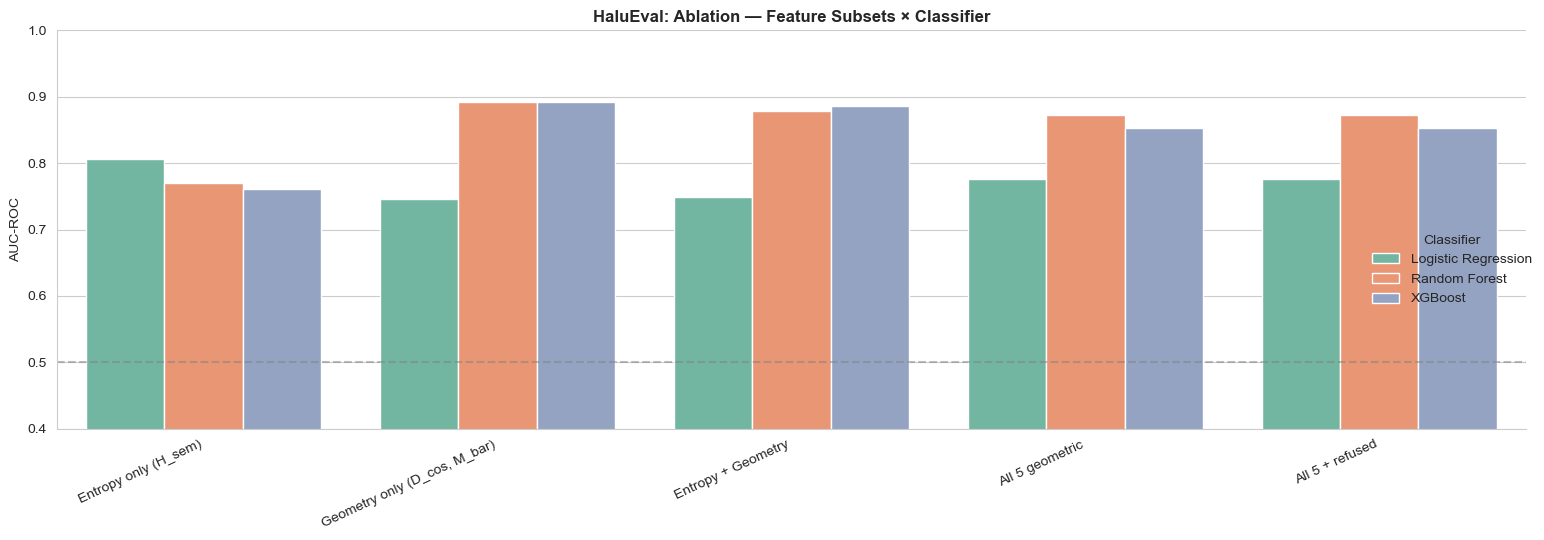

In [30]:
g = sns.catplot(
    data=df_clf, kind='bar',
    x='Variant', y='AUC_mean', hue='Classifier',
    palette='Set2', height=5.5, aspect=2.5,
    capsize=0.05, errwidth=1.5,
)
g.ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
g.ax.set_ylim(0.4, 1.0)
g.ax.set_title('HaluEval: Ablation — Feature Subsets × Classifier', fontweight='bold')
g.ax.set_ylabel('AUC-ROC')
g.ax.set_xlabel('')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig16_ablation.png'), dpi=150, bbox_inches='tight')
plt.show()


### Per-Domain Classification

In [31]:
domain_clf_rows = []

for dom in analysis_domains:
    df_d = feat_df[feat_df['domain_canonical'] == dom]
    X_d = df_d[GEO_FEATURES].values
    y_d = df_d['label'].values
    if len(np.unique(y_d)) < 2:
        print(f'  Skipping {dom} (single class)')
        continue
    X_d_sc = StandardScaler().fit_transform(X_d)
    for clf_name, clf in classifiers.items():
        n_folds = min(5, min(Counter(y_d).values()))
        if n_folds < 2:
            continue
        cv_d = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_SEED)
        scores = cross_val_score(clf, X_d_sc, y_d, cv=cv_d, scoring='roc_auc')
        domain_clf_rows.append({
            'Domain': dom, 'Classifier': clf_name,
            'AUC_mean': scores.mean(), 'AUC_std': scores.std(),
            'n_questions': len(df_d),
        })

if excluded_domains:
    print(f'Excluded (< {MIN_QUESTIONS_FOR_ANALYSIS} questions): {excluded_domains}')

df_dom_clf = pd.DataFrame(domain_clf_rows)
df_dom_clf.to_csv(os.path.join(OUTPUT_DIR, 'classification_per_domain.csv'), index=False)
display(df_dom_clf.pivot_table(index='Domain', columns='Classifier', values='AUC_mean').round(3))


Excluded (< 10 questions): ['Medicine & Health']


Classifier,Logistic Regression,Random Forest,XGBoost
Domain,,,
Entertainment,0.701,0.906,0.500
Humanities,0.723,0.890,0.874
STEM,0.908,0.818,0.867
Social Sciences,0.851,0.776,0.647


### Bootstrap AUC Confidence Intervals

In [32]:
rng_boot = np.random.default_rng(RANDOM_SEED)

print('Global bootstrap (RF, 5 geometric features):')
auc_boot_global = []
for _ in range(N_BOOTSTRAP):
    idx = rng_boot.choice(len(y_all), len(y_all), replace=True)
    oob = np.setdiff1d(np.arange(len(y_all)), idx)
    if len(oob) < 10 or len(np.unique(y_all[oob])) < 2:
        continue
    if len(np.unique(y_all[idx])) < 2:
        continue
    rf_b = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=0)
    rf_b.fit(X_geo_sc[idx], y_all[idx])
    proba = rf_b.predict_proba(X_geo_sc[oob])[:, 1]
    auc_boot_global.append(roc_auc_score(y_all[oob], proba))

auc_boot_global = np.array(auc_boot_global)
ci_lo, ci_hi = np.percentile(auc_boot_global, [2.5, 97.5])
print(f'  AUC = {auc_boot_global.mean():.4f}  95% CI [{ci_lo:.4f}, {ci_hi:.4f}]')


Global bootstrap (RF, 5 geometric features):
  AUC = 0.8763  95% CI [0.7954, 0.9474]


In [33]:
boot_rows = []
print('Per-domain bootstrap:')
for dom in analysis_domains:
    df_d = feat_df[feat_df['domain_canonical'] == dom]
    X_d = StandardScaler().fit_transform(df_d[GEO_FEATURES].values)
    y_d = df_d['label'].values
    if len(np.unique(y_d)) < 2:
        continue
    auc_list = []
    for _ in range(N_BOOTSTRAP):
        idx = rng_boot.choice(len(y_d), len(y_d), replace=True)
        oob = np.setdiff1d(np.arange(len(y_d)), idx)
        if len(oob) < 5 or len(np.unique(y_d[oob])) < 2:
            continue
        if len(np.unique(y_d[idx])) < 2:
            continue
        rf_b = RandomForestClassifier(n_estimators=50, random_state=0)
        rf_b.fit(X_d[idx], y_d[idx])
        proba = rf_b.predict_proba(X_d[oob])[:, 1]
        auc_list.append(roc_auc_score(y_d[oob], proba))
    if len(auc_list) < 10:
        continue
    arr = np.array(auc_list)
    lo, hi = np.percentile(arr, [2.5, 97.5])
    boot_rows.append({
        'Domain': dom, 'AUC_mean': arr.mean(),
        'CI_low': lo, 'CI_high': hi, 'n_questions': len(df_d),
    })
    print(f'  {dom:30s}  AUC={arr.mean():.3f}  [{lo:.3f}, {hi:.3f}]  (n={len(df_d)})')

if excluded_domains:
    print(f'\nExcluded: {excluded_domains}')

df_boot = pd.DataFrame(boot_rows).sort_values('AUC_mean', ascending=True)
df_boot.to_csv(os.path.join(OUTPUT_DIR, 'bootstrap_auc.csv'), index=False)


Per-domain bootstrap:
  Entertainment                   AUC=0.879  [0.500, 1.000]  (n=19)
  Humanities                      AUC=0.828  [0.638, 0.971]  (n=248)
  STEM                            AUC=0.764  [0.378, 1.000]  (n=105)
  Social Sciences                 AUC=0.717  [0.344, 1.000]  (n=88)

Excluded: ['Medicine & Health']


### ROC Curves

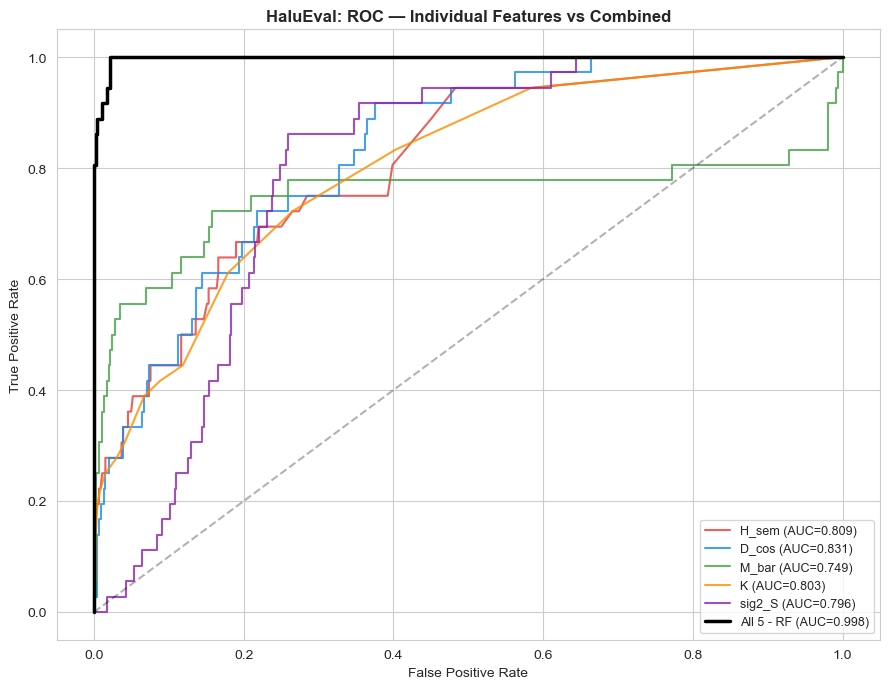

In [34]:
fig, ax = plt.subplots(figsize=(9, 7))
feat_colors = ['#E53935', '#1E88E5', '#43A047', '#FB8C00', '#8E24AA']

for i, (feat, color) in enumerate(zip(GEO_FEATURES, feat_colors)):
    vals = X_geo_sc[:, i]
    fpr, tpr, _ = roc_curve(y_all, vals)
    auc_s = roc_auc_score(y_all, vals)
    ax.plot(fpr, tpr, color=color, linewidth=1.5, alpha=0.8,
            label=f'{feat} (AUC={auc_s:.3f})')

rf_full = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_SEED)
rf_full.fit(X_geo_sc, y_all)
y_scores = rf_full.predict_proba(X_geo_sc)[:, 1]
fpr_a, tpr_a, _ = roc_curve(y_all, y_scores)
auc_a = roc_auc_score(y_all, y_scores)
ax.plot(fpr_a, tpr_a, color='black', linewidth=2.5,
        label=f'All 5 - RF (AUC={auc_a:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('HaluEval: ROC — Individual Features vs Combined', fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig17_roc_features.png'), dpi=150, bbox_inches='tight')
plt.show()


## Feature Importance and SHAP

XGBoost GAIN per domain + SHAP beeswarm plots (analysis domains only).


In [35]:
import shap

xgb_imp = xgb.XGBClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.08,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    eval_metric='logloss', random_state=RANDOM_SEED, verbosity=0,
)

importance_data = {}
for dom in analysis_domains:
    df_d = feat_df[feat_df['domain_canonical'] == dom]
    X_d = StandardScaler().fit_transform(df_d[GEO_FEATURES].values)
    y_d = df_d['label'].values
    if len(np.unique(y_d)) < 2:
        importance_data[dom] = np.zeros(5)
        continue
    xgb_imp.fit(X_d, y_d)
    booster = xgb_imp.get_booster()
    gain_dict = booster.get_score(importance_type='gain')
    gains = np.array([gain_dict.get(f'f{i}', 0.0) for i in range(5)], dtype=float)
    total = gains.sum()
    importance_data[dom] = gains / total if total > 0 else gains

df_imp = pd.DataFrame(importance_data, index=GEO_FEATURES).T
print('Normalized GAIN importance per domain:')
display(df_imp.round(3))


Normalized GAIN importance per domain:


,H_sem,D_cos,M_bar,K,sig2_S
Entertainment,0.493,0.000,0.000,0.000,0.507
Humanities,0.151,0.132,0.374,0.136,0.207
Law & Business,0.371,0.000,0.629,0.000,0.000
STEM,0.141,0.344,0.240,0.063,0.212
Social Sciences,0.346,0.072,0.093,0.399,0.091
Sports,0.000,0.000,0.000,0.000,0.000


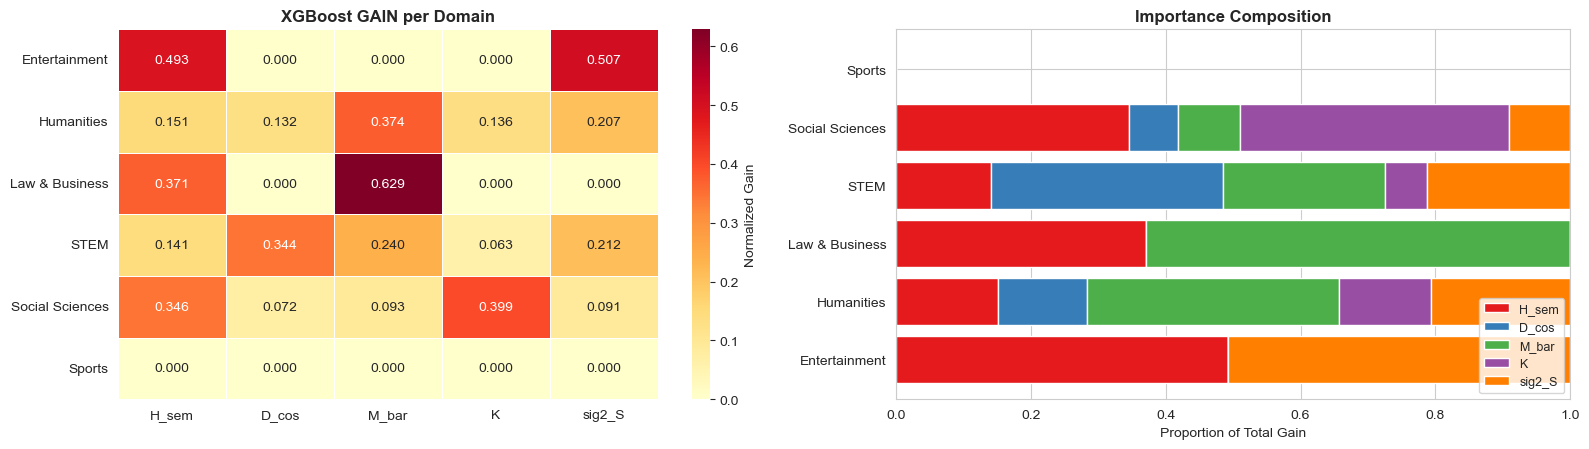

In [36]:
feat_colors_list = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(analysis_domains) * 0.6 + 1)))

sns.heatmap(df_imp, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=df_imp.values.max(),
            ax=axes[0], linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Normalized Gain'})
axes[0].set_title('XGBoost GAIN per Domain', fontweight='bold')

bottoms = np.zeros(len(df_imp))
for feat, color in zip(GEO_FEATURES, feat_colors_list):
    vals = df_imp[feat].values
    axes[1].barh(df_imp.index, vals, left=bottoms, color=color, label=feat)
    bottoms += vals
axes[1].set_xlabel('Proportion of Total Gain')
axes[1].set_title('Importance Composition', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig18_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()


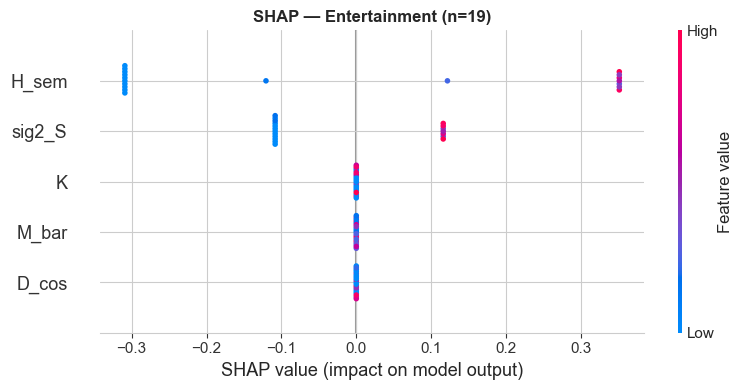

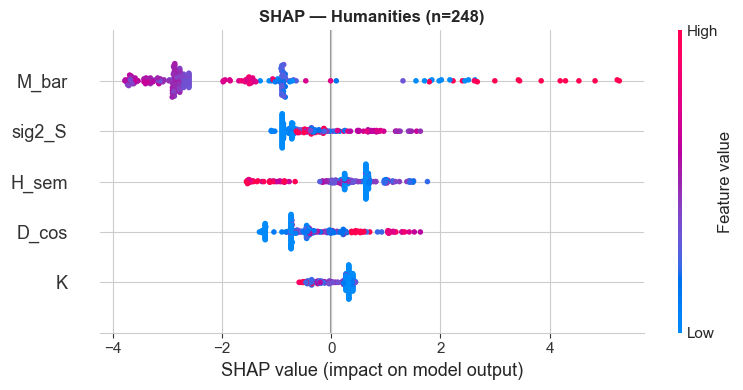

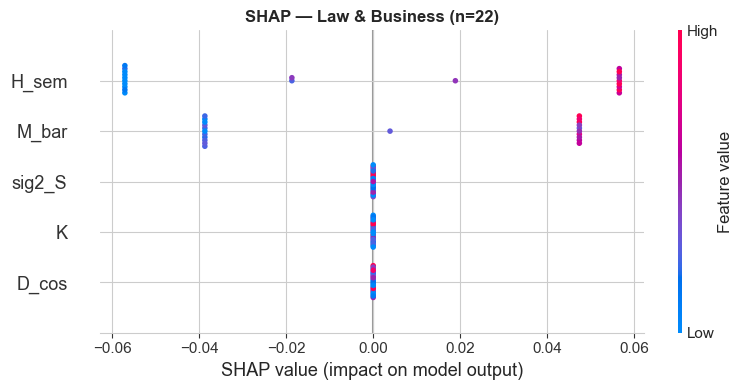

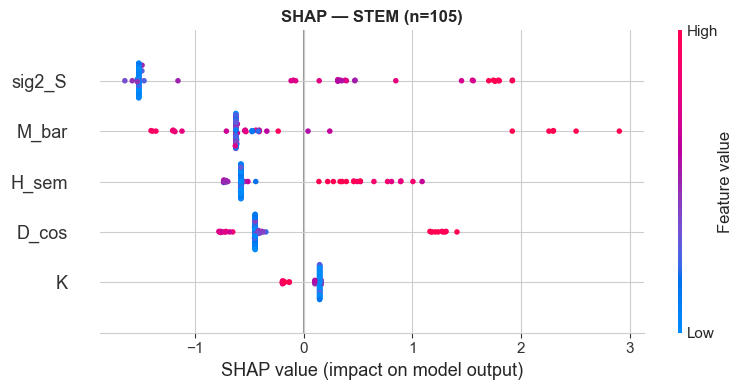

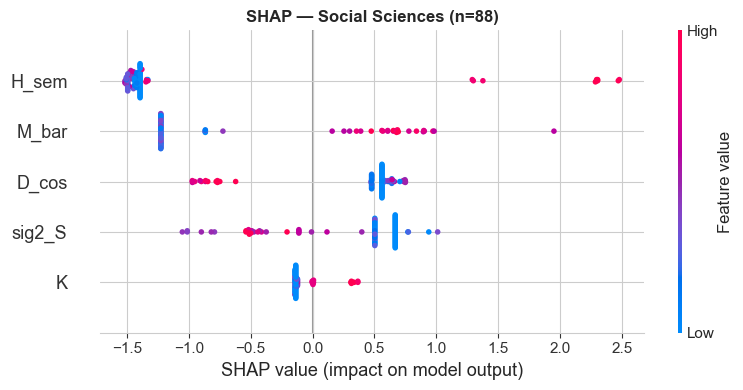

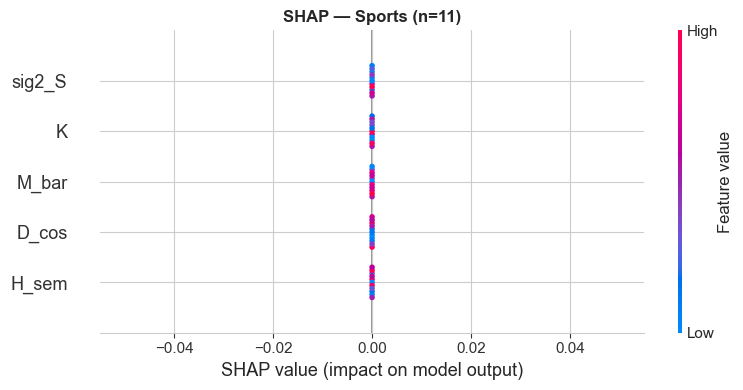

Excluded from per-domain SHAP: ['Medicine & Health']


In [37]:
xgb_shap = xgb.XGBClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.08,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    eval_metric='logloss', random_state=RANDOM_SEED, verbosity=0,
)

for dom in analysis_domains:
    df_d = feat_df[feat_df['domain_canonical'] == dom]
    X_d = StandardScaler().fit_transform(df_d[GEO_FEATURES].values)
    y_d = df_d['label'].values
    if len(np.unique(y_d)) < 2:
        print(f'Skipping {dom}')
        continue
    xgb_shap.fit(X_d, y_d)
    explainer = shap.TreeExplainer(xgb_shap)
    sv = explainer.shap_values(X_d)
    if isinstance(sv, list):
        sv = sv[1]
    plt.figure(figsize=(8, 4))
    shap.summary_plot(sv, X_d, feature_names=GEO_FEATURES, show=False, plot_size=None)
    plt.title(f'SHAP — {dom} (n={len(df_d)})', fontweight='bold')
    plt.tight_layout()
    plt.show()

if excluded_domains:
    print(f'Excluded from per-domain SHAP: {excluded_domains}')


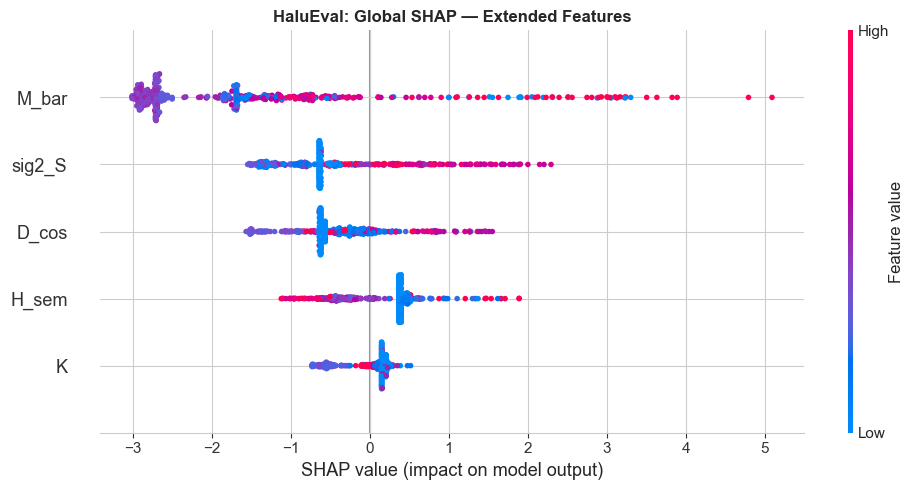

In [38]:
# Global SHAP on extended features
xgb_shap.fit(X_ext_sc, y_all)
explainer = shap.TreeExplainer(xgb_shap)
sv_global = explainer.shap_values(X_ext_sc)
if isinstance(sv_global, list):
    sv_global = sv_global[1]

plt.figure(figsize=(10, 5))
shap.summary_plot(sv_global, X_ext_sc, feature_names=EXTENDED_FEATURES,
                  show=False, plot_size=None)
plt.title('HaluEval: Global SHAP — Extended Features', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig19_shap_global.png'), dpi=150, bbox_inches='tight')
plt.show()


## UMAP 


Running UMAP on 8000 points...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


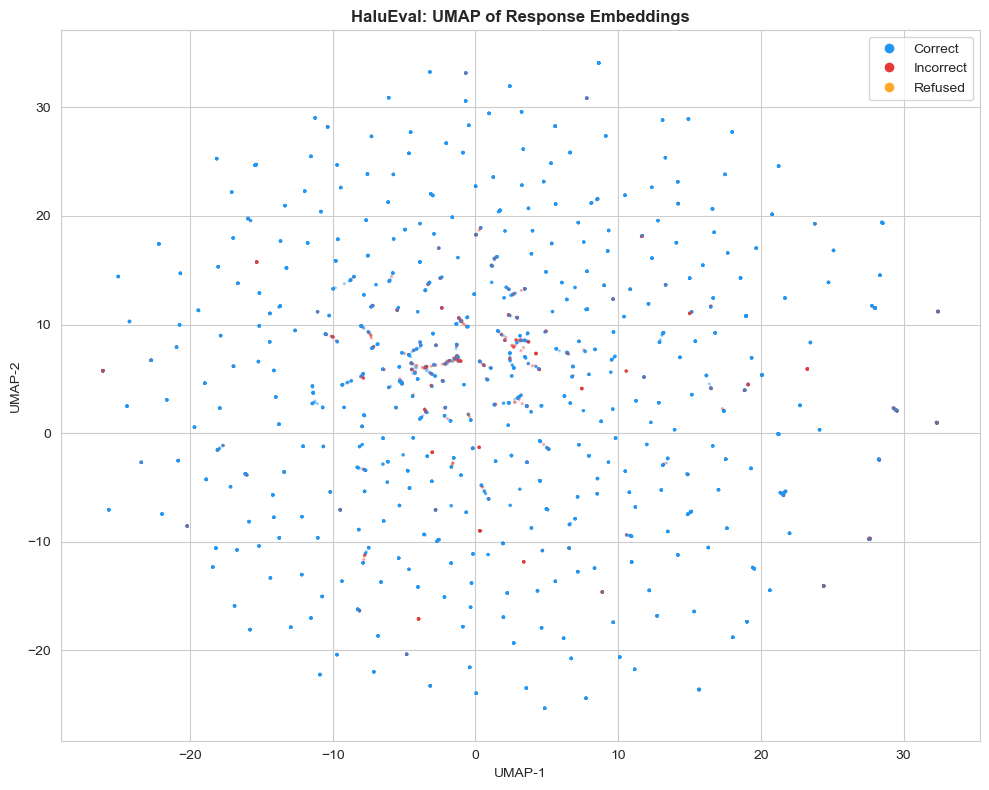

In [39]:
try:
    import umap

    max_pts = 8000
    rng_u = np.random.default_rng(RANDOM_SEED)
    if all_embeddings.shape[0] > max_pts:
        idx_sub = rng_u.choice(all_embeddings.shape[0], max_pts, replace=False)
    else:
        idx_sub = np.arange(all_embeddings.shape[0])

    emb_sub = all_embeddings[idx_sub]
    lab_sub = df['correctness'].values[idx_sub]

    print(f'Running UMAP on {len(idx_sub)} points...')
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM_SEED)
    proj = reducer.fit_transform(emb_sub)

    fig = plot_umap(proj, lab_sub, title='HaluEval: UMAP of Response Embeddings')
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig20_umap.png'), dpi=120, bbox_inches='tight')
    plt.show()

except ImportError:
    print('umap-learn not installed, skipping UMAP.')


## Summary

In [40]:
print('=' * 70)
print('HALUEVAL HALLUCINATION DETECTION — RESULTS SUMMARY')
print('=' * 70)
print(f'  Dataset: HaluEval')
print(f'  Total questions (raw): {df["prompt_id"].nunique()}')
print(f'  Questions analyzed: {len(feat_df)}')
print(f'  Questions skipped (all refused): {skipped}')
print(f'  Samples per question: 20')
print(f'  Canonical domains: {len(all_domains)}')
print(f'  Domains in ML (>= {MIN_QUESTIONS_FOR_ANALYSIS}): {len(analysis_domains)}')
if excluded_domains:
    print(f'  Excluded from ML: {excluded_domains}')
print()

resp_counts = df['correctness'].value_counts()
print('  Response-level breakdown:')
for lab in LABEL_ORDER:
    if lab in resp_counts.index:
        pct = resp_counts[lab] / len(df) * 100
        print(f'    {lab:12s}: {resp_counts[lab]:6d}  ({pct:.1f}%)')
print()

print(f'  Binary label (strict):')
print(f'    Correct: {(feat_df["label"]==0).sum()}, Hallucinated: {(feat_df["label"]==1).sum()}')
print(f'    Rate: {feat_df["label"].mean()*100:.1f}%')
print()

print(f'  Permutation test (entropy):')
print(f'    delta = {delta_obs:.4f} bits, p = {perm_pval:.6f}')
print()

print(f'  Bootstrap AUC (RF, 5 geometric features):')
print(f'    AUC = {auc_boot_global.mean():.4f}, 95% CI [{ci_lo:.4f}, {ci_hi:.4f}]')
print()

best = df_clf.loc[df_clf['AUC_mean'].idxmax()]
print(f'  Best classifier config:')
print(f'    {best["Classifier"]} / {best["Variant"]} — AUC={best["AUC_mean"]:.4f}')
print()

print(f'  Top feature by domain (XGBoost GAIN):')
for dom, row in df_imp.iterrows():
    top = row.idxmax()
    print(f'    {dom:30s}: {top} ({row[top]:.3f})')
print()
print(f'  Outputs: {OUTPUT_DIR}/')
print('=' * 70)


HALUEVAL HALLUCINATION DETECTION — RESULTS SUMMARY
  Dataset: HaluEval
  Total questions (raw): 500
  Questions analyzed: 500
  Questions skipped (all refused): 0
  Samples per question: 20
  Canonical domains: 7
  Domains in ML (>= 10): 6
  Excluded from ML: ['Medicine & Health']

  Response-level breakdown:
    correct     :   8984  (89.8%)
    incorrect   :   1006  (10.1%)
    refused     :     10  (0.1%)

  Binary label (strict):
    Correct: 464, Hallucinated: 36
    Rate: 7.2%

  Permutation test (entropy):
    delta = 1.2933 bits, p = 0.000000

  Bootstrap AUC (RF, 5 geometric features):
    AUC = 0.8763, 95% CI [0.7954, 0.9474]

  Best classifier config:
    Random Forest / Geometry only (D_cos, M_bar) — AUC=0.8926

  Top feature by domain (XGBoost GAIN):
    Entertainment                 : sig2_S (0.507)
    Humanities                    : M_bar (0.374)
    Law & Business                : M_bar (0.629)
    STEM                          : D_cos (0.344)
    Social Sciences      